COFFEE SHOP SALES - DATA EXPLORATION

[STEP 1] Loading Dataset...
--------------------------------------------------------------------------------
✓ Dataset loaded successfully!
Total rows: 149,116
Total columns: 11

[STEP 2] Dataset Overview...
--------------------------------------------------------------------------------

Shape: 149,116 rows × 11 columns

Data Types:
transaction_id               int64
transaction_date    datetime64[us]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location                 str
product_id                   int64
unit_price                 float64
product_category               str
product_type                   str
product_detail                 str
dtype: object

First 5 Rows:
   transaction_id transaction_date transaction_time  transaction_qty  \
0               1       2023-01-01         07:06:11                2   
1               2       2023-01-01         07:08:56                2

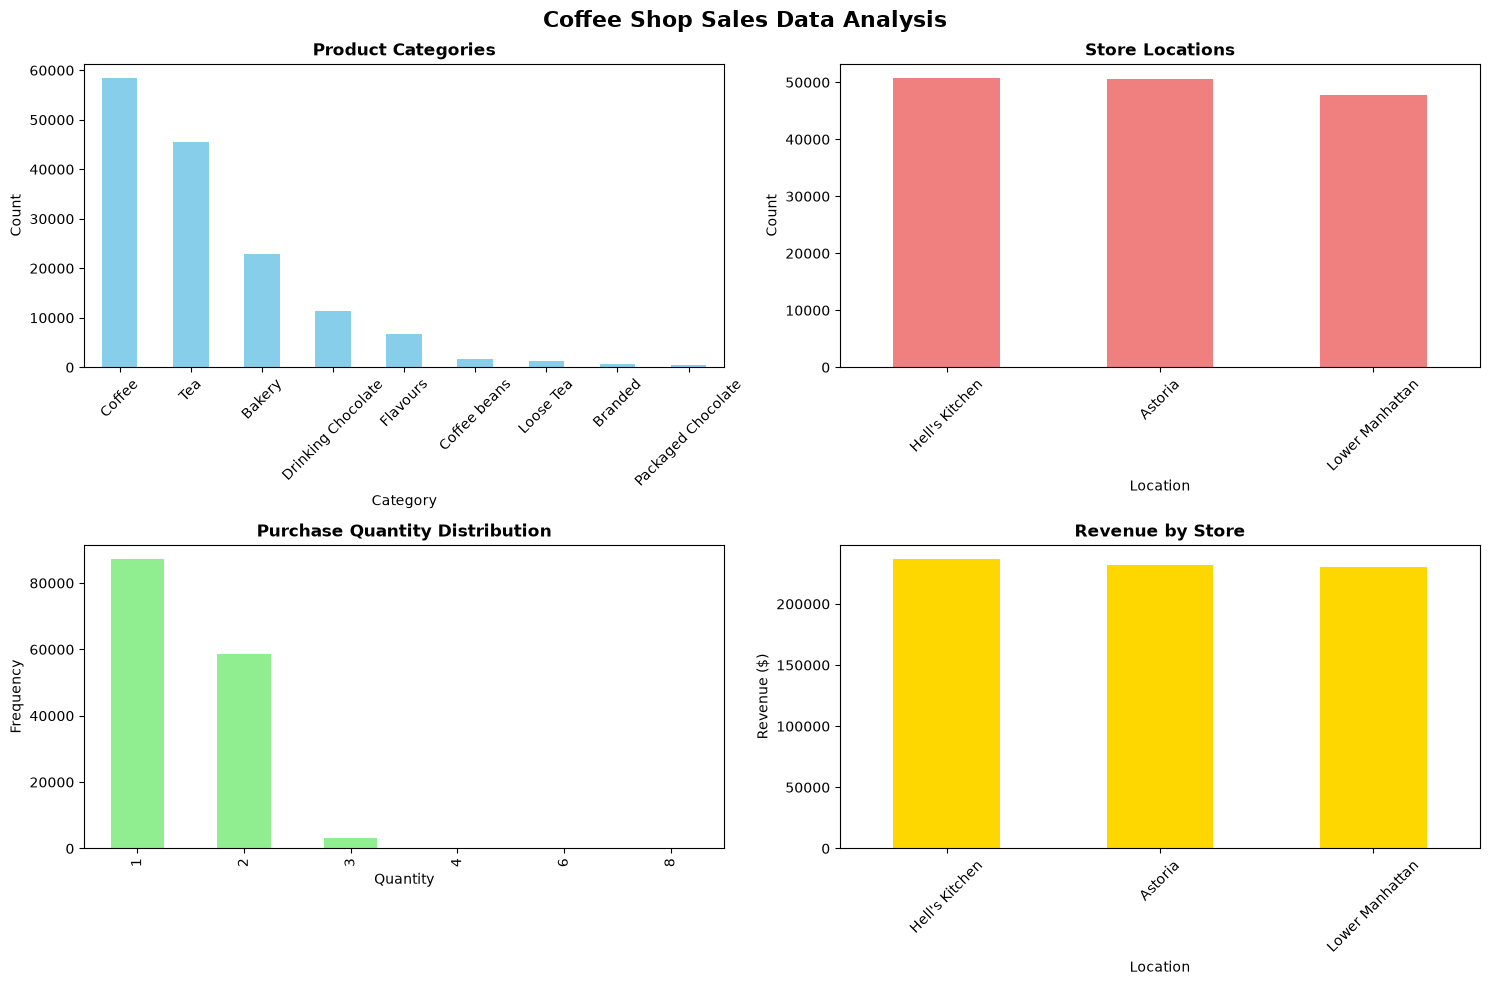


✓ DATA EXPLORATION COMPLETED!


In [1]:
# COFFEE SHOP SALES ANALYSIS - DATA EXPLORATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*80)
print("COFFEE SHOP SALES - DATA EXPLORATION")
print("="*80)

# ================================================================================
# STEP 1: LOAD THE DATASET
# ================================================================================

print("\n[STEP 1] Loading Dataset...")
print("-"*80)

df = pd.read_excel('C:/Users/dan41/Desktop/Coffee Shop Sales.xlsx')

print("✓ Dataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")

# ================================================================================
# STEP 2: DATASET OVERVIEW
# ================================================================================

print("\n[STEP 2] Dataset Overview...")
print("-"*80)

print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 Rows:")
print(df.head())

# ================================================================================
# STEP 3: DATA QUALITY CHECK
# ================================================================================

print("\n[STEP 3] Data Quality Check...")
print("-"*80)

missing = df.isnull().sum()
print("\nMissing Values:")
print(missing)

if missing.sum() == 0:
    print("\n✓ No missing values - Data is clean!")

# ================================================================================
# STEP 4: STATISTICAL SUMMARY
# ================================================================================

print("\n[STEP 4] Statistical Summary...")
print("-"*80)

print("\nBasic Statistics:")
print(df.describe())

# ================================================================================
# STEP 5: CATEGORICAL DATA
# ================================================================================

print("\n[STEP 5] Categorical Data Analysis...")
print("-"*80)

print("\nProduct Categories:")
print(df['product_category'].value_counts())

print("\nStore Locations:")
print(df['store_location'].value_counts())

# ================================================================================
# STEP 6: KEY STATISTICS
# ================================================================================

print("\n[STEP 6] Key Statistics...")
print("-"*80)

print("\nTransaction Quantity:")
print(f"  Min: {df['transaction_qty'].min()}")
print(f"  Max: {df['transaction_qty'].max()}")
print(f"  Avg: {df['transaction_qty'].mean():.2f}")
print(f"  Median: {df['transaction_qty'].median():.2f}")

print("\nUnit Price:")
print(f"  Min: ${df['unit_price'].min():.2f}")
print(f"  Max: ${df['unit_price'].max():.2f}")
print(f"  Avg: ${df['unit_price'].mean():.2f}")

df['revenue'] = df['transaction_qty'] * df['unit_price']

print("\nRevenue:")
print(f"  Total: ${df['revenue'].sum():,.2f}")
print(f"  Avg: ${df['revenue'].mean():.2f}")

# ================================================================================
# STEP 7: UNIQUE VALUES
# ================================================================================

print("\n[STEP 7] Unique Values Count...")
print("-"*80)

print(f"Unique Stores: {df['store_id'].nunique()}")
print(f"Unique Products: {df['product_id'].nunique()}")
print(f"Unique Categories: {df['product_category'].nunique()}")
print(f"Unique Product Types: {df['product_type'].nunique()}")
print(f"Unique Dates: {df['transaction_date'].nunique()}")

# ================================================================================
# STEP 8: QUANTITY DISTRIBUTION
# ================================================================================

print("\n[STEP 8] Transaction Quantity Distribution...")
print("-"*80)

print("\nQuantity Frequency:")
print(df['transaction_qty'].value_counts().sort_index())

# ================================================================================
# STEP 9: TOP PRODUCTS AND STORES
# ================================================================================

print("\n[STEP 9] Top Analysis...")
print("-"*80)

print("\nTop 5 Products by Volume:")
print(df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False).head(5))

print("\nTop 5 Stores by Revenue:")
print(df.groupby('store_location')['revenue'].sum().sort_values(ascending=False).head(5))

# ================================================================================
# STEP 10: DATA VISUALIZATION
# ================================================================================

print("\n[STEP 10] Creating Visualizations...")
print("-"*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Coffee Shop Sales Data Analysis', fontsize=16, fontweight='bold')

# Plot 1
df['product_category'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Product Categories', fontweight='bold')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2
df['store_location'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Store Locations', fontweight='bold')
axes[0, 1].set_xlabel('Location')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3
df['transaction_qty'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Purchase Quantity Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Quantity')
axes[1, 0].set_ylabel('Frequency')

# Plot 4
df.groupby('store_location')['revenue'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Revenue by Store', fontweight='bold')
axes[1, 1].set_xlabel('Location')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data_visualization.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualizations saved as 'data_visualization.png'")
plt.show()

# ================================================================================
# FINAL MESSAGE
# ================================================================================

print("\n" + "="*80)
print("✓ DATA EXPLORATION COMPLETED!")
print("="*80)